In [22]:
import os
import argparse
from types import SimpleNamespace
from pathlib import Path

import cortex

import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import io, warnings
from contextlib import contextmanager, redirect_stdout, redirect_stderr
@contextmanager
def suppress_print():
    """Silence stdout/stderr and warnings inside the with-block."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        f, e = io.StringIO(), io.StringIO()
        with redirect_stdout(f), redirect_stderr(e):
            yield

import shutil, os, subprocess as sp
import re

def robust_inkscape_version():
    env = os.environ.copy()
    env.setdefault('LANG','C.UTF-8'); env.setdefault('LC_ALL','C.UTF-8')
    p = sp.run(['inkscape','--version'], stdout=sp.PIPE, stderr=sp.STDOUT, text=True, env=env)
    m = re.search(r'Inkscape\s+([0-9]+(?:\.[0-9]+)*)', p.stdout or "")
    return m.group(1) if m else '0'   # fallback minimal

import cortex, cortex.svgoverlay as svo
svo.INKSCAPE_VERSION = robust_inkscape_version()
print("Patched INKSCAPE_VERSION =", svo.INKSCAPE_VERSION)

os.chdir("/engram/nklab/pf2477/brain_decoding/")
from brain_adapter.dataset import nsd_topk_parcel_dataset, get_dominant_roi_per_parcel

Patched INKSCAPE_VERSION = 1.3


In [23]:
subj=1
args = SimpleNamespace(
        subj=subj,
        backbone_arch="dinov2_q",
        data_dir="/engram/nklab/datasets/natural_scene_dataset/model_training_datasets/neural_data",
        imgs_dir="/engram/nklab/datasets/natural_scene_dataset/nsddata_stimuli/stimuli/nsd",
        parcel_dir="/engram/nklab/algonauts/ethan/whole_brain_encoder/parcels/schaefer",
        hemi=None,
)
args.tokenizer = None
args.gen_size = 512
args.topk = 100
print("Setting up test configuration for subject ", subj)

dataset = nsd_topk_parcel_dataset(args, split='test', transform=None, topk=args.topk)
print(len(dataset), "samples in the dataset")
# print(dataset.selected_parcel_idx)
print(len(dataset.selected_parcel_idx['lh']), "left hemisphere parcels")
print(len(dataset.selected_parcel_idx['rh']), "right hemisphere parcels")

Setting up test configuration for subject  1
Testing on subject: 1
515 samples in the dataset
100 left hemisphere parcels
100 right hemisphere parcels


In [24]:
neural_data_path = Path("/engram/nklab/datasets/natural_scene_dataset/model_training_datasets/neural_data")
metadata = np.load(neural_data_path / f"metadata_sub-{subj:02}.npy", allow_pickle=True).item()

all_roi_names = list(metadata['lh_rois'].keys())[:24] + list(metadata['rh_rois'].keys())[:24]
print(f' all_roi_names: {all_roi_names}, len: {len(all_roi_names)}')

min_overlap_threshold = 0.5
dominant_rois = get_dominant_roi_per_parcel(dataset, metadata, all_roi_names, min_overlap_threshold=min_overlap_threshold)

print("\n" + "="*50)
print(f"DOMINANT ROI PER PARCEL (>{min_overlap_threshold*100}% overlap)")
print("="*50)

matched_rois = set()
for hemi in ['lh', 'rh']:
    print(f"\n{hemi.upper()} Hemisphere:")
    cnt = 0
    for parcel_idx, roi_name, overlap, num_voxels in dominant_rois[hemi]:
        # parcel_idx is the original parcel id in 500 parcels
        if roi_name:
            print(f"Parcel {parcel_idx:3d}: {roi_name:20s} ({overlap:.1%}) in {num_voxels} Schaefer voxels")
            cnt += 1
            matched_rois.add(roi_name)
        else:
            print(f"Parcel {parcel_idx:3d}: No ROI has >= {min_overlap_threshold:.1%} overlap")

    print(f"Total parcels with dominant ROI in {hemi.upper()}: {cnt}")

print(matched_rois)


 all_roi_names: ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'EBA', 'FBA-1', 'FBA-2', 'mTL-bodies', 'OFA', 'FFA-1', 'FFA-2', 'mTL-faces', 'aTL-faces', 'OPA', 'PPA', 'RSC', 'OWFA', 'VWFA-1', 'VWFA-2', 'mfs-words', 'mTL-words', 'V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'EBA', 'FBA-1', 'FBA-2', 'mTL-bodies', 'OFA', 'FFA-1', 'FFA-2', 'mTL-faces', 'aTL-faces', 'OPA', 'PPA', 'RSC', 'OWFA', 'VWFA-1', 'VWFA-2', 'mfs-words', 'mTL-words'], len: 48
Processing 100 LH parcels with matrix operations...


LH: 100%|██████████| 100/100 [00:00<00:00, 265.40it/s]


Processing 100 RH parcels with matrix operations...


RH: 100%|██████████| 100/100 [00:00<00:00, 257.15it/s]


DOMINANT ROI PER PARCEL (>50.0% overlap)

LH Hemisphere:
Parcel   2: V1d                  (67.9%) in 184 Schaefer voxels
Parcel  21: EBA                  (100.0%) in 293 Schaefer voxels
Parcel  26: V2d                  (81.8%) in 192 Schaefer voxels
Parcel  27: V3d                  (52.0%) in 204 Schaefer voxels
Parcel  11: V2v                  (55.4%) in 408 Schaefer voxels
Parcel   0: V1v                  (55.0%) in 318 Schaefer voxels
Parcel   1: V1v                  (87.1%) in 233 Schaefer voxels
Parcel 157: EBA                  (95.5%) in 336 Schaefer voxels
Parcel   3: V1d                  (100.0%) in 241 Schaefer voxels
Parcel 158: EBA                  (100.0%) in 85 Schaefer voxels
Parcel  45: PPA                  (100.0%) in 381 Schaefer voxels
Parcel  24: V3d                  (54.0%) in 326 Schaefer voxels
Parcel 160: EBA                  (91.5%) in 201 Schaefer voxels
Parcel  22: V1d                  (69.3%) in 218 Schaefer voxels
Parcel   9: No ROI has >= 50.0% overlap
Par

In [25]:
if min_overlap_threshold == 0.75:
    roi_groups = {
        # Early / retinotopic visual
        "V1": ["V1v", "V1d"],
        "V2": ["V2v", "V2d"],
        "V4": ["hV4"],

        # Higher-level ventral stream
        "Face": ["FFA-1", "FFA-2"],
        "Body": ["FBA-2", "EBA"],
        "Scene": ["PPA", "OPA", "RSC"],
        "Word": ["VWFA-1", "VWFA-2", "mfs-words"],
    }

if min_overlap_threshold == 0.5:
    roi_groups = {
        # Early / retinotopic visual
        "V1":  ["V1v", "V1d"],
        "V2":  ["V2v", "V2d"],
        "V3":  ["V3v", "V3d"],
        "V4": ["hV4"],

        # Higher-level ventral stream
        "Face": ["FFA-1", "FFA-2", "OFA"],
        "Body": ["FBA-2", "EBA"],
        "Scene": ["PPA", "OPA", "RSC"],
        "Word": ["VWFA-1", "VWFA-2", "OWFA", "mfs-words"],
    }

if min_overlap_threshold <= 0.25:
    roi_groups = {
        # Early / retinotopic visual
        "V1": ["V1v", "V1d"],
        "V2": ["V2v", "V2d"],
        "V3": ["V3v", "V3d"],
        "V4": ["hV4"],

        # Higher-level ventral stream
        "Face": ["OFA", "FFA-1", "FFA-2"],
        "Body": ["EBA", "FBA-1", "FBA-2"],
        "Scene": ["PPA", "OPA", "RSC"],
        "Word": ["VWFA-1", "VWFA-2", "OWFA", "mfs-words"],
    }

1
(1, 512, 512, 3)
['down_blocks.0.attentions.0.transformer_blocks.0.attn2', 'down_blocks.0.attentions.1.transformer_blocks.0.attn2', 'down_blocks.1.attentions.0.transformer_blocks.0.attn2', 'down_blocks.1.attentions.1.transformer_blocks.0.attn2', 'down_blocks.2.attentions.0.transformer_blocks.0.attn2', 'down_blocks.2.attentions.1.transformer_blocks.0.attn2', 'mid_block.attentions.0.transformer_blocks.0.attn2', 'up_blocks.1.attentions.0.transformer_blocks.0.attn2', 'up_blocks.1.attentions.1.transformer_blocks.0.attn2', 'up_blocks.1.attentions.2.transformer_blocks.0.attn2', 'up_blocks.2.attentions.0.transformer_blocks.0.attn2', 'up_blocks.2.attentions.1.transformer_blocks.0.attn2', 'up_blocks.2.attentions.2.transformer_blocks.0.attn2', 'up_blocks.3.attentions.0.transformer_blocks.0.attn2', 'up_blocks.3.attentions.1.transformer_blocks.0.attn2', 'up_blocks.3.attentions.2.transformer_blocks.0.attn2']
['timestep', 'attention_maps', 'clean_predictions']


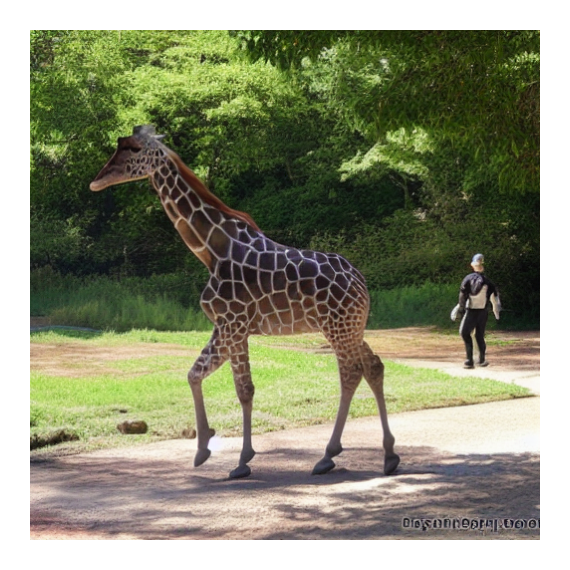

Clean prediction range: [0, 255]


In [26]:
attn_file = "brain_adapter/attn_maps/08_16_2025-18_03/epoch_200/subset/sample_000300/time_step_001.npz"

npz_data = np.load(attn_file, allow_pickle=True)

time_step = int(attn_file.split("/")[-1].replace(".npz", "").split("_")[-1])
attn_maps = npz_data['attention_maps'].item()
clean_preds = npz_data['clean_predictions']
layer_names = list(attn_maps.keys())
print(time_step)
print(clean_preds.shape)
print(layer_names)
print(list(npz_data.keys()))

# Plot the noisy and clean prediction images
fig, axes = plt.subplots(1, 1, figsize=(2, 2), dpi=300)

# Plot clean prediction
axes.imshow(clean_preds[0])  # Remove batch dimension if present
axes.axis('off')

plt.tight_layout()
plt.show()

# import os
# os.chdir("/engram/nklab/pf2477/brain_decoding/figures")
# plt.axis("off")
# plt.savefig("300_pred.png", bbox_inches="tight", pad_inches=0)

# Print some info about the images
print(f"Clean prediction range: [{clean_preds.min():.0f}, {clean_preds.max():.0f}]")

INTEGRATED ATTENTION ON CORTEX (Query-weighted across all layers)
Integrating attention across 16 layers with query weighting...
Layer integration summary:
   • down_blocks.0.attentions.0.transformer_blocks.0.attn2: 4096 queries (15.2% weight)
   • down_blocks.0.attentions.1.transformer_blocks.0.attn2: 4096 queries (15.2% weight)
   • down_blocks.1.attentions.0.transformer_blocks.0.attn2: 1024 queries (3.8% weight)
   • down_blocks.1.attentions.1.transformer_blocks.0.attn2: 1024 queries (3.8% weight)
   • down_blocks.2.attentions.0.transformer_blocks.0.attn2: 256 queries (1.0% weight)
   • down_blocks.2.attentions.1.transformer_blocks.0.attn2: 256 queries (1.0% weight)
   • mid_block.attentions.0.transformer_blocks.0.attn2: 64 queries (0.2% weight)
   • up_blocks.1.attentions.0.transformer_blocks.0.attn2: 256 queries (1.0% weight)
   • up_blocks.1.attentions.1.transformer_blocks.0.attn2: 256 queries (1.0% weight)
   • up_blocks.1.attentions.2.transformer_blocks.0.attn2: 256 queries (1.

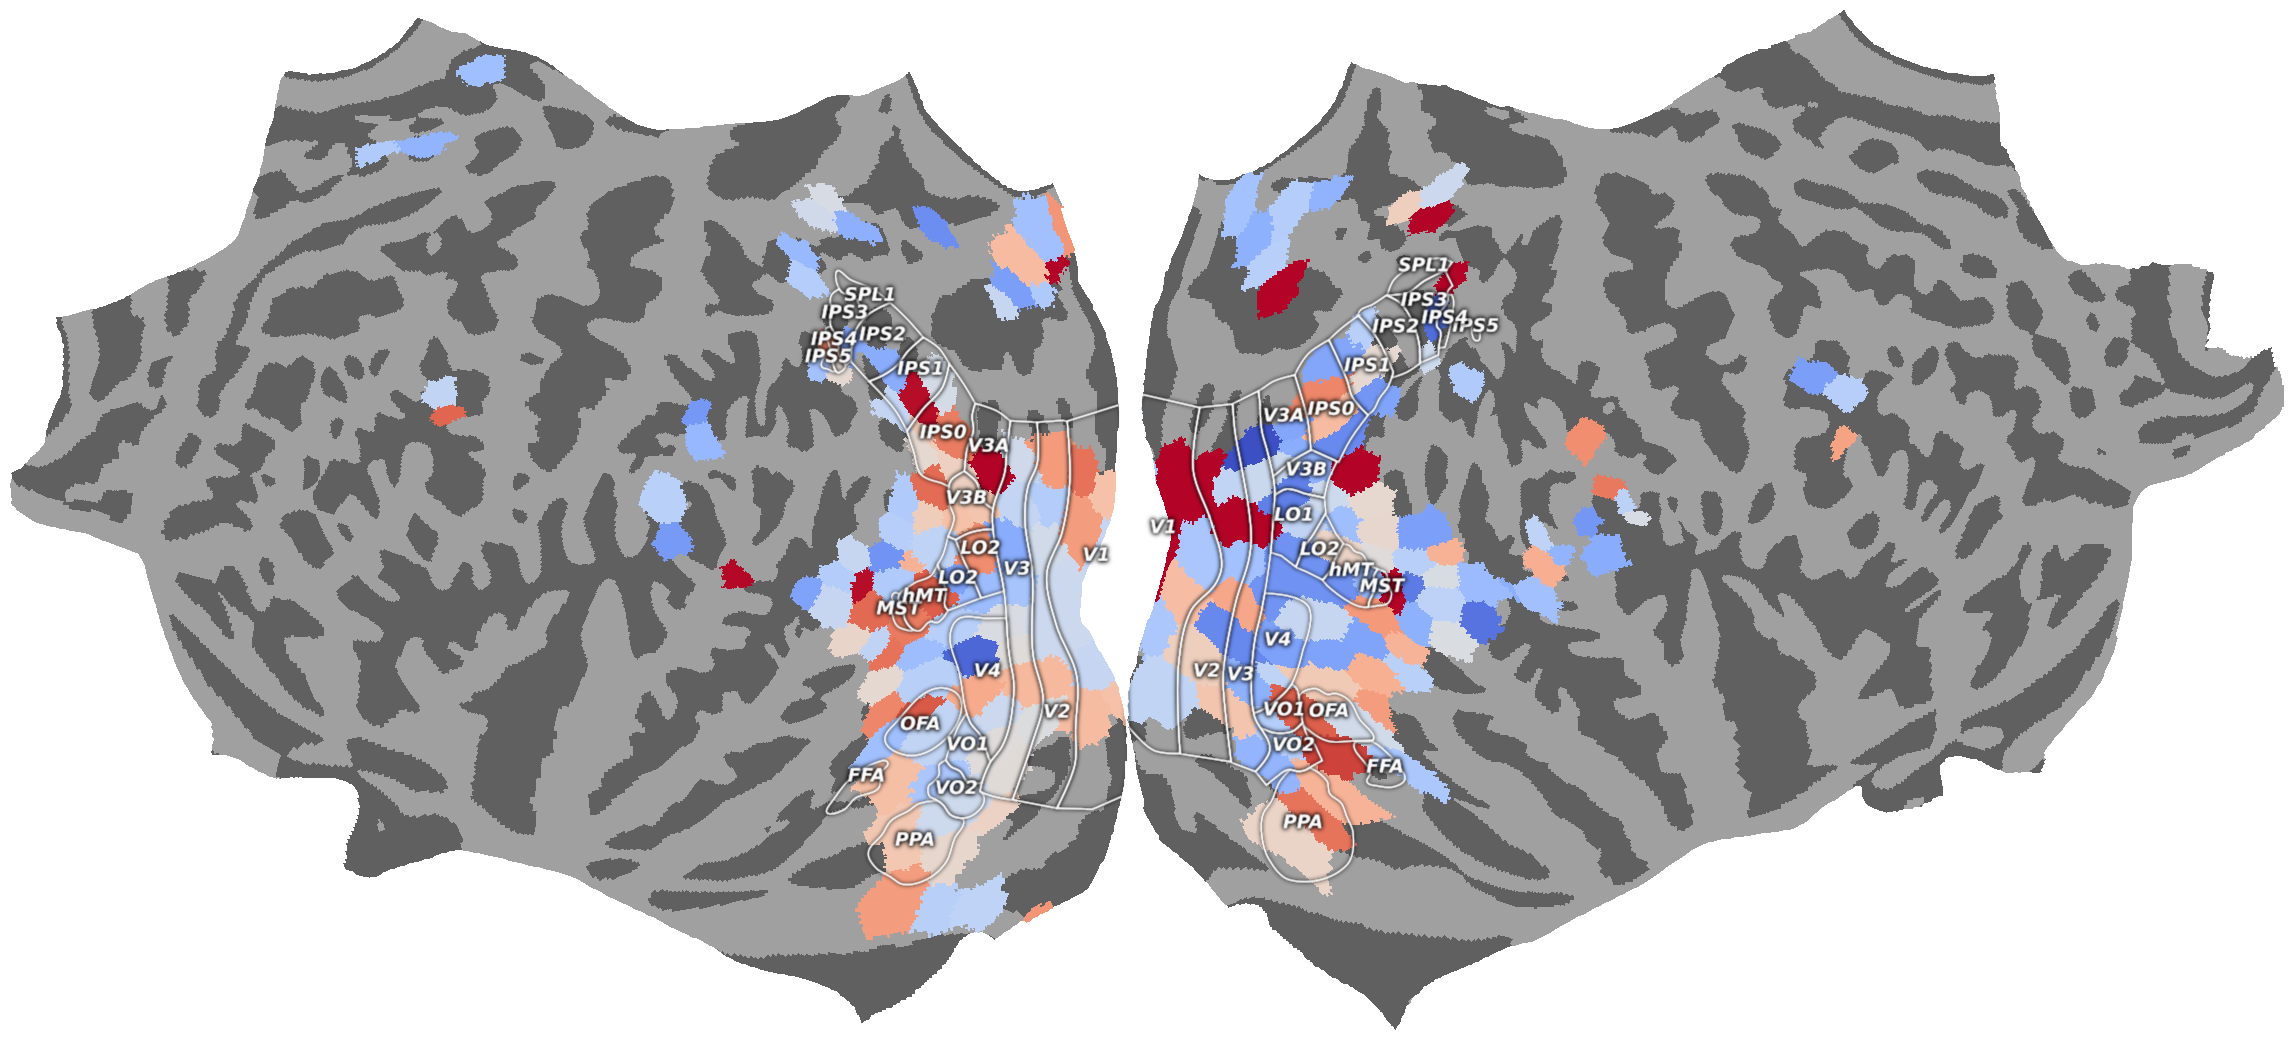

Attention statistics:
  Total condition tokens: 200
  Vertices with attention data: 51543
  Enrichment ratio range: [0.35, 1.65] (center: 1.0)
  Normalized PCV sum: 1.0000
  Mean enrichment (all parcels): 1.00x
PCV range: [0.0000, 0.0183]
Unlabeled vertices: 276141 vertices (transparent)
Mean PCV (labeled vertices): 0.0050 (1.00x enrichment)


In [63]:
def visualize_pcv_on_cortex(
    attn_maps, dataset, metadata, 
    subject="fsaverage", cmap='coolwarm', with_curvature=True, normalize_weights=True,
    roi_group=None, dominant_rois=None
):
    """
    Paint attention weights onto cortical surface using Pycortex for all parcels with layer integration.
    
    Args:
        attn_maps: Dictionary of attention maps for different layers OR single attention tensor [num_heads, spatial_tokens, condition_tokens]
        dataset: Dataset with parcel information
        metadata: Brain metadata with ROI mappings
        subject: Pycortex subject name
        cmap: Colormap for visualization (recommend 'coolwarm' for diverging)
        with_curvature: Whether to show cortical curvature
        normalize_weights: Whether to normalize attention weights to sum to 1
        roi_group: List of ROI names to highlight. If specified, only parcels with these ROIs will show attention,
                  while all other parcels become unlabeled (shown in gray).
        dominant_rois: Output from get_dominant_roi_per_parcel (required if roi_group is specified)
    """
    # Ensure subject exists
    if subject not in cortex.db.subjects:
        cortex.download_subject(subject)
    
    # Check if roi_group filtering is requested
    if roi_group is not None:
        if dominant_rois is None:
            raise ValueError("dominant_rois must be provided when roi_group is specified")
        print(f"ROI Group Filter: {roi_group}")
    
    # Create parcel-to-ROI mapping for filtering
    parcel_roi_mapping = {}
    if roi_group is not None:
        for hemi in ['lh', 'rh']:
            for parcel_idx, roi_name, overlap, num_voxels in dominant_rois[hemi]:
                parcel_roi_mapping[(hemi, parcel_idx)] = roi_name
    
    # Handle different input types
    if not isinstance(attn_maps, dict):
        raise ValueError("attn_maps must be a dictionary of attention maps")
    # Query-weighted integration across all layers
    layer_names = list(attn_maps.keys())
    print(f"Integrating attention across {len(layer_names)} layers with query weighting...")
    
    integrated_attention = None
    total_query_weight = 0
    layer_query_counts = {}
    
    for layer_name in layer_names:
        if layer_name not in attn_maps:
            print(f"Layer {layer_name} not found in attention maps")
            continue
            
        # Get attention map for this layer
        layer_attn = attn_maps[layer_name]
        
        # Get dimensions: [heads, spatial_queries, tokens]
        num_heads, num_queries, num_tokens = layer_attn.shape
        layer_query_counts[layer_name] = num_queries
        
        # Average across all spatial tokens and heads
        layer_attn_processed = layer_attn.mean(axis=(0, 1))  # Average across heads and spatial tokens
        
        # Weight by query count (Q_len) to account for different spatial resolutions
        query_weight = num_queries
        
        # Accumulate with query weighting
        if integrated_attention is None:
            integrated_attention = layer_attn_processed * query_weight
        else:
            integrated_attention += layer_attn_processed * query_weight
        
        total_query_weight += query_weight
    
    # Normalize by total query weight to get properly weighted average
    if integrated_attention is not None and total_query_weight > 0:
        attn_weights = integrated_attention / total_query_weight
        
        print(f"Layer integration summary:")
        for layer_name in layer_names:
            if layer_name in layer_query_counts:
                weight_pct = (layer_query_counts[layer_name] / total_query_weight) * 100
                print(f"   • {layer_name}: {layer_query_counts[layer_name]} queries ({weight_pct:.1f}% weight)")
        
    else:
        print("No valid attention data found for integration")
        return None
            
    print(f"Final attention weights shape: {attn_weights.shape}")
    
    # Normalize weights if requested
    if normalize_weights and len(attn_weights) > 0:
        weight_sum = attn_weights.sum()
        if weight_sum > 0:
            attn_weights = attn_weights / weight_sum
            print(f"Normalized attention weights to sum to 1 (originally summed to {weight_sum:.4f})")
        else:
            print("Warning: All attention weights are zero, skipping normalization")
    
    # Get hemisphere sizes
    lh_hemi_size = len(next(iter(metadata['lh_rois'].values())))
    rh_hemi_size = len(next(iter(metadata['rh_rois'].values())))
    
    # Initialize cortical surface with zeros
    lh_values = np.zeros(lh_hemi_size, dtype=np.float32)
    rh_values = np.zeros(rh_hemi_size, dtype=np.float32)
    
    # Get selected voxel indices for each parcel
    sel_vox = dataset.get_selected_voxel_indices()
    
    # Paint attention weights onto cortical surface for all parcels
    for hemi, values in [("lh", lh_values), ("rh", rh_values)]:
        parcel_indices = dataset.selected_parcel_idx[hemi]
        
        for parcel_pos, parcel_idx in enumerate(parcel_indices):
            # Get voxel indices for this parcel
            vox_indices = sel_vox[hemi][parcel_pos]
            vox_indices = vox_indices.cpu().numpy() if isinstance(vox_indices, torch.Tensor) else np.asarray(vox_indices)
            
            if vox_indices.size == 0:
                continue
            
            # Check if this parcel should be included based on roi_group filter
            if roi_group is not None:
                parcel_roi = parcel_roi_mapping.get((hemi, parcel_idx), None)
                if parcel_roi not in roi_group:
                    # Skip this parcel - it will remain as background (0)
                    continue
            
            # Calculate token index (LH: 0-99, RH: 100-199)
            if hemi == "lh":
                token_idx = parcel_pos
            else:
                token_idx = parcel_pos + dataset.num_parcels // 2  # RH tokens start at index 100
            
            # Get attention weight for this token
            if token_idx < len(attn_weights):
                weight = attn_weights[token_idx]
                # Paint this weight onto all voxels in the parcel
                values[vox_indices] = weight
    
    # Combine hemispheres for Pycortex
    cortex_data = np.concatenate([lh_values, rh_values])
    
    # 1) Choose what to plot: enrichment ratio (center = uniform attention)
    p = len(attn_weights)  # Number of parcels/tokens
    pcv = cortex_data  # True PCV per vertex (already parcel→vertex mapped)
    values = p * pcv  # Enrichment ratio (1.0 = uniform attention)
    center = 1.0
    
    # 2) Create mask for unlabeled vertices (where PCV = 0)
    is_unlabeled_mask = (pcv == 0)
    
    # Apply mask: set unlabeled areas to NaN
    values_masked = np.where(is_unlabeled_mask, np.nan, values)
    
    # 3) Percentile-based normalization around center for comparability
    vals_labeled = values[~is_unlabeled_mask]
    if roi_group is not None:
        # When filtering by ROI group, use global percentiles for consistency
        low, high = np.nanpercentile(vals_labeled, [1, 99])
    else:
        # For all parcels, use slightly tighter percentiles
        low, high = np.nanpercentile(vals_labeled, [5, 95])

    # Ensure the range is symmetric around center for diverging colormaps
    if cmap in ['coolwarm', 'RdBu_r', 'bwr', 'seismic']:
        max_deviation = max(abs(low - center), abs(high - center))
        low = center - max_deviation
        high = center + max_deviation
    
    # 4) Create colormap and set color for unlabeled areas
    color_map = matplotlib.colormaps.get_cmap(cmap).copy()
    # color_map.set_bad(color='white', alpha=0)  # Transparent for unlabeled areas
    # color_map.set_under(color='lightgray')   # color for sentinel values
    color_map.set_bad(color='white', alpha=0)

    # 5) Create Pycortex vertex object with true data + proper normalization
    vertex_data = cortex.Vertex(
        values_masked,
        subject=subject,
        cmap=color_map,
        vmin=low,
        vmax=high,
    )
    
    # Apply two-slope normalization for better visualization around center
    from matplotlib.colors import TwoSlopeNorm
    if hasattr(vertex_data, 'norm'):
        vertex_data.norm = TwoSlopeNorm(vmin=low, vcenter=center, vmax=high)
    
    # 6) Visualize without colorbar
    with suppress_print():
        cortex.quickshow(vertex_data, with_curvature=True, with_colorbar=False)
    
    # Beautify the plot
    fig = plt.gcf()
    

    for ax in fig.get_axes():
        ax.set_frame_on(False)
        ax.set_xticks([])
        ax.set_yticks([])
    
    plt.show()
    
    # Print statistics
    total_tokens = len(attn_weights)
    num_painted_parcels = np.sum(~is_unlabeled_mask)
    
    print(f"Attention statistics:")
    print(f"  Total condition tokens: {total_tokens}")
    print(f"  Vertices with attention data: {num_painted_parcels}")
    print(f"  Enrichment ratio range: [{low:.2f}, {high:.2f}] (center: {center:.1f})")
    
    if roi_group is not None:
        # Count how many parcels were included/excluded by ROI filter
        included_parcels = 0
        excluded_parcels = 0
        roi_attention_scores = {}  # Store attention scores for each ROI
        
        for hemi in ['lh', 'rh']:
            for parcel_pos, parcel_idx in enumerate(dataset.selected_parcel_idx[hemi]):
                parcel_roi = parcel_roi_mapping.get((hemi, parcel_idx), None)
                if parcel_roi in roi_group:
                    included_parcels += 1
                    
                    # Calculate token index and get attention score
                    if hemi == "lh":
                        token_idx = parcel_pos
                    else:
                        token_idx = parcel_pos + dataset.num_parcels // 2
                    
                    if token_idx < len(attn_weights):
                        attention_score = attn_weights[token_idx]
                        
                        # Accumulate attention scores by ROI name
                        if parcel_roi not in roi_attention_scores:
                            roi_attention_scores[parcel_roi] = []
                        roi_attention_scores[parcel_roi].append(attention_score)
                else:
                    excluded_parcels += 1
        
        print(f"  ROI filtering: {included_parcels} parcels included, {excluded_parcels} parcels excluded")
        print(f"  Showing attention only for ROIs: {roi_group}")
        
        # Display attention scores for each ROI in the group
        if roi_attention_scores:
            print(f"  Attention scores by ROI:")
            total_roi_attention = 0
            for roi_name in sorted(roi_attention_scores.keys()):
                roi_scores = np.array(roi_attention_scores[roi_name])
                mean_score = roi_scores.mean()
                total_score = roi_scores.sum()
                mean_enrichment = p * mean_score  # Convert to enrichment ratio
                num_parcels = len(roi_scores)
                total_roi_attention += total_score
                
                print(f"    • {roi_name:12s}: {mean_enrichment:.2f}x enrichment, {total_score:.4f} total ({num_parcels} parcels)")
            
            print(f"  Total attention for ROI group: {total_roi_attention:.4f}")
            
            if normalize_weights:
                total_possible = attn_weights.sum()
                roi_proportion = total_roi_attention / total_possible if total_possible > 0 else 0
                print(f"  ROI group proportion of total attention: {roi_proportion:.1%}")
        else:
            print(f"  No attention scores found for ROI group (no matching parcels)")
    
    if normalize_weights:
        print(f"  Normalized PCV sum: {attn_weights.sum():.4f}")
        print(f"  Mean enrichment (all parcels): {(p * attn_weights.mean()):.2f}x")
    else:
        print(f"  Original attention weights sum: {attn_weights.sum():.4f}")
    
    print(f"PCV range: [{cortex_data.min():.4f}, {cortex_data.max():.4f}]")
    print(f"Unlabeled vertices: {np.sum(is_unlabeled_mask)} vertices (transparent)")
    if np.any(~is_unlabeled_mask):
        mean_pcv = cortex_data[~is_unlabeled_mask].mean()
        print(f"Mean PCV (labeled vertices): {mean_pcv:.4f} ({(p * mean_pcv):.2f}x enrichment)")
    
    return cortex_data

# Example usage: Visualize integrated attention weights on cortex for all parcels
print("="*60)
print("INTEGRATED ATTENTION ON CORTEX (Query-weighted across all layers)")
print("="*60)

cortex_attention_integrated = visualize_pcv_on_cortex(
    attn_maps,           # Dictionary of attention maps from all layers
    dataset,             # Dataset
    metadata,            # Metadata
    subject="fsaverage",
    cmap='coolwarm',     # Diverging colormap works well for enrichment ratios
    normalize_weights=True,  # Normalize weights to sum to 1
    roi_group=None,          # Show all ROIs (set to specific ROI list to filter)
    dominant_rois=dominant_rois  # Provide dominant ROI mapping for filtering
)

INTEGRATED ATTENTION ON CORTEX (Query-weighted across all layers)


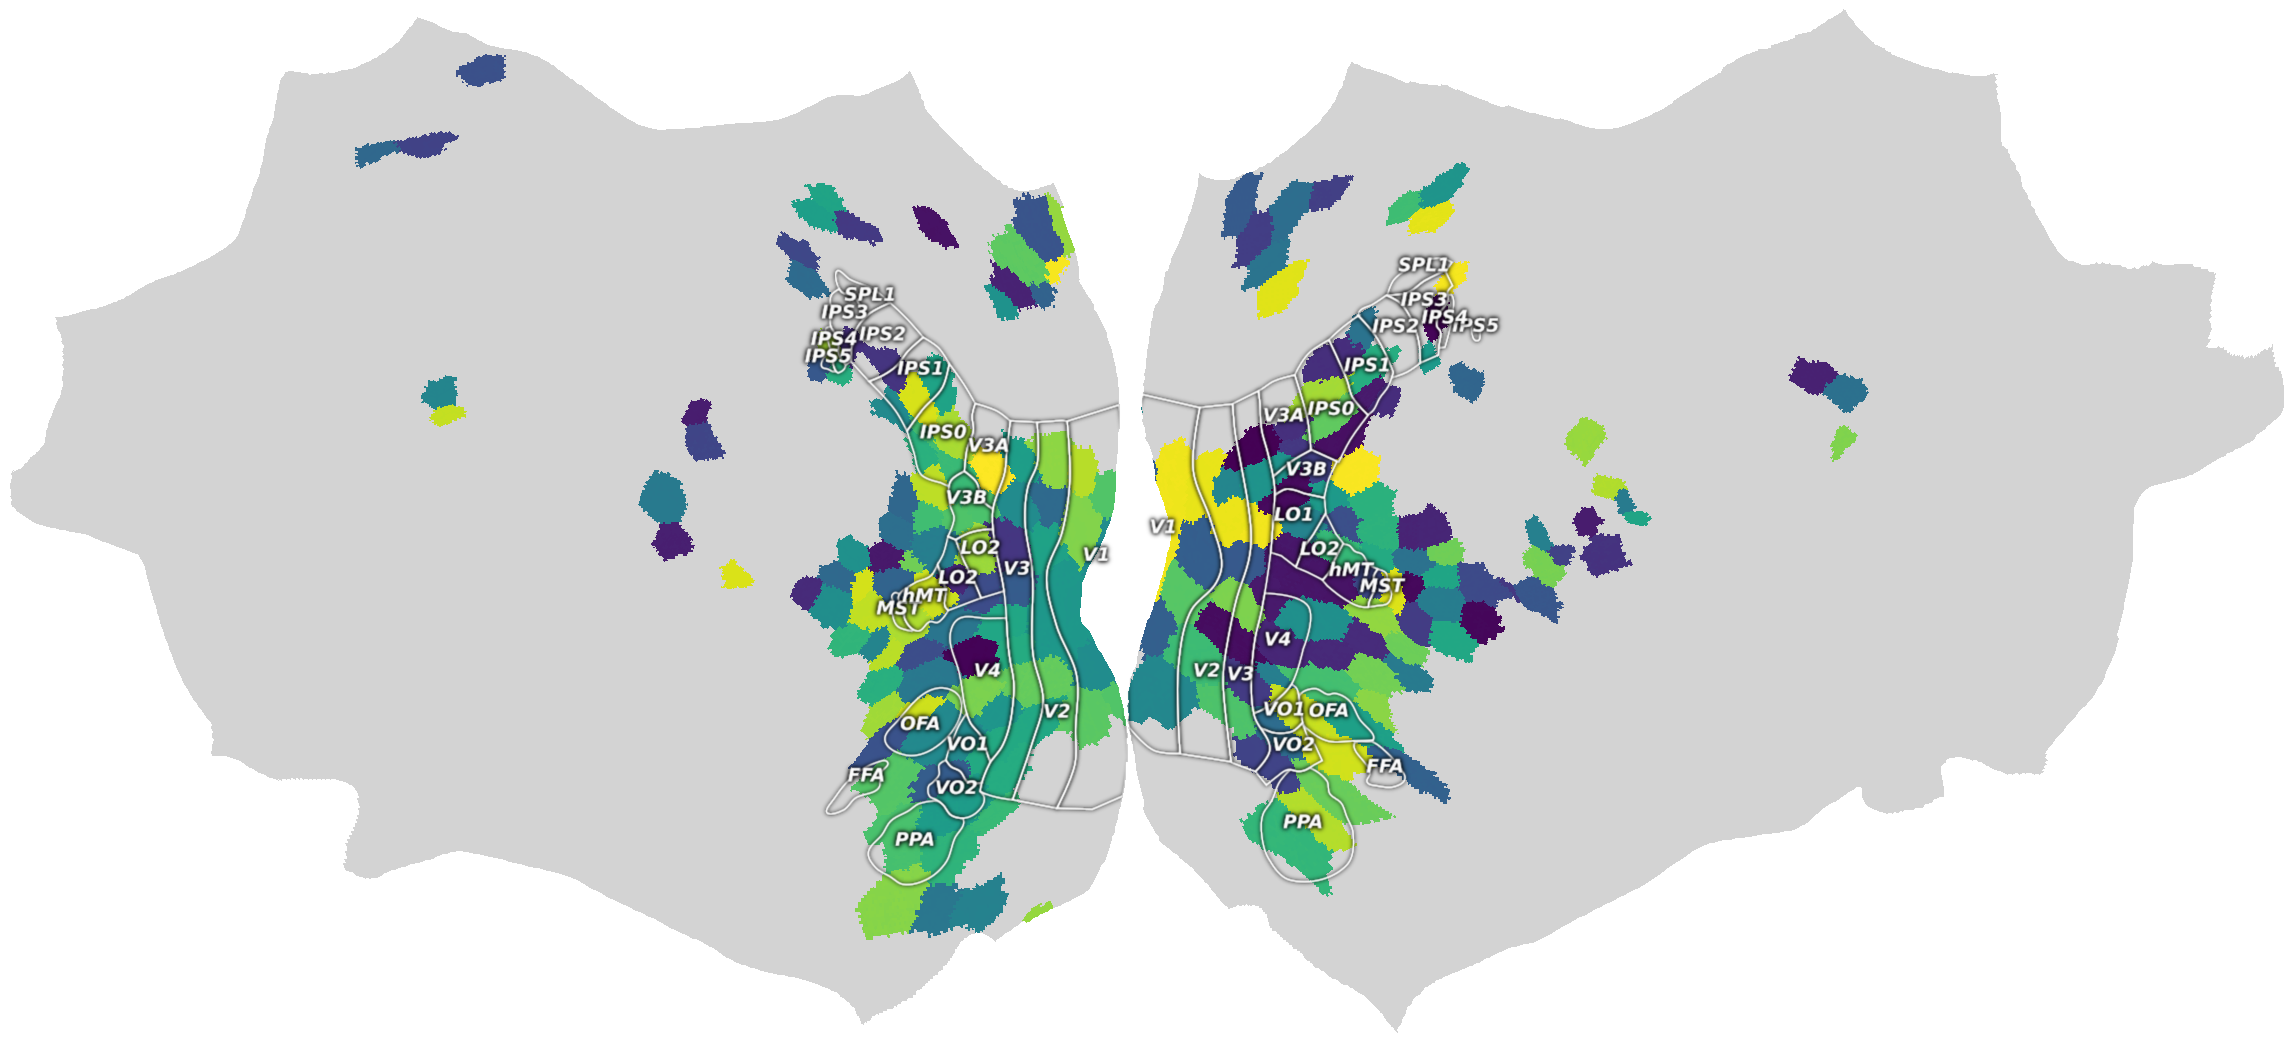

In [79]:
def visualize_pcv_on_cortex_rank(
    attn_maps, dataset, metadata, 
    subject="fsaverage", cmap='viridis', with_curvature=True,
    roi_group=None, dominant_rois=None
):
    """
    Paint rank-normalized attention weights (PCV) onto cortical surface using Pycortex.
    Each parcel is colored by its relative rank (0 = weakest, 1 = strongest).

    Args:
        attn_maps: Dictionary of attention maps for different layers OR single attention tensor
        dataset: Dataset with parcel information
        metadata: Brain metadata with ROI mappings
        subject: Pycortex subject name
        cmap: Sequential colormap (default: viridis)
        with_curvature: Whether to show cortical curvature
        roi_group: If specified, only parcels with these ROIs are shown; others in light grey
        dominant_rois: Output from get_dominant_roi_per_parcel (required if roi_group is specified)
    """
    import cortex
    import numpy as np
    import torch
    import matplotlib
    from contextlib import suppress

    # --- Layer integration (same as before) ---
    layer_names = list(attn_maps.keys())
    integrated_attention = None
    total_query_weight = 0
    for layer_name in layer_names:
        layer_attn = attn_maps[layer_name]   # [heads, queries, tokens]
        num_heads, num_queries, num_tokens = layer_attn.shape
        layer_attn_processed = layer_attn.mean(axis=(0, 1))
        if integrated_attention is None:
            integrated_attention = layer_attn_processed * num_queries
        else:
            integrated_attention += layer_attn_processed * num_queries
        total_query_weight += num_queries
    attn_weights = integrated_attention / total_query_weight
    if isinstance(attn_weights, torch.Tensor):
        attn_weights = attn_weights.cpu().numpy()

    # --- Map to cortex surface ---
    lh_size = len(next(iter(metadata['lh_rois'].values())))
    rh_size = len(next(iter(metadata['rh_rois'].values())))
    lh_values = -np.ones(lh_size, dtype=np.float32)
    rh_values = -np.ones(rh_size, dtype=np.float32)
    sel_vox = dataset.get_selected_voxel_indices()

    parcel_roi_mapping = {}
    if roi_group is not None:
        for hemi in ['lh', 'rh']:
            for parcel_idx, roi_name, overlap, nvox in dominant_rois[hemi]:
                parcel_roi_mapping[(hemi, parcel_idx)] = roi_name

    for hemi, values in [("lh", lh_values), ("rh", rh_values)]:
        for parcel_pos, parcel_idx in enumerate(dataset.selected_parcel_idx[hemi]):
            vox_indices = sel_vox[hemi][parcel_pos]
            vox_indices = vox_indices.cpu().numpy() if isinstance(vox_indices, torch.Tensor) else np.asarray(vox_indices)
            if vox_indices.size == 0:
                continue
            if roi_group is not None:
                roi_name = parcel_roi_mapping.get((hemi, parcel_idx), None)
                if roi_name not in roi_group:
                    continue
            token_idx = parcel_pos if hemi == "lh" else parcel_pos + dataset.num_parcels // 2
            if token_idx < len(attn_weights):
                values[vox_indices] = attn_weights[token_idx]

    cortex_data = np.concatenate([lh_values, rh_values])

    # --- Rank normalization ---
    vals = cortex_data.copy()
    valid_mask = vals > 0
    ranks = np.argsort(np.argsort(vals[valid_mask]))
    normed_ranks = ranks / (len(ranks) - 1 + 1e-8)
    rank_values = np.full_like(vals, -2.0, dtype=float)  # background = -2
    rank_values[valid_mask] = normed_ranks

    # --- Colormap ---
    cmap_obj = matplotlib.colormaps.get_cmap(cmap).copy()
    cmap_obj.set_bad("white")   # unlabeled cortex
    cmap_obj.set_under("lightgrey ")     # outside background

    # --- Vertex for Pycortex ---
    vertex_data = cortex.Vertex(rank_values, subject=subject, cmap=cmap_obj, vmin=0, vmax=1)

    with suppress_print():
        cortex.quickshow(vertex_data, with_curvature=with_curvature, with_colorbar=False)

    return cortex_data


# Example usage: Visualize integrated attention weights on cortex for all parcels
print("="*60)
print("INTEGRATED ATTENTION ON CORTEX (Query-weighted across all layers)")
print("="*60)

cortex_attention_integrated = visualize_pcv_on_cortex_rank(
    attn_maps,           # Dictionary of attention maps from all layers
    dataset,             # Dataset
    metadata,            # Metadata
    subject="fsaverage",
    cmap='viridis',     # Diverging colormap works well for enrichment ratios
    roi_group=None,          # Show all ROIs (set to specific ROI list to filter)
    dominant_rois=dominant_rois  # Provide dominant ROI mapping for filtering
)